<a href="https://colab.research.google.com/github/Ruchithavarma17/Deep-Learning-lab-programs/blob/main/Denoising_Autoencoder_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.2589 - val_loss: 0.1969
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1801 - val_loss: 0.1681
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1618 - val_loss: 0.1553
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1537 - val_loss: 0.1498
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1487 - val_loss: 0.1452
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1444 - val_loss: 0.1418
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1408 - val_loss: 0.1383
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1379 - val_loss: 0.1357
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1356 - val_loss: 0.1341
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.1336 - val_loss: 0.1320
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


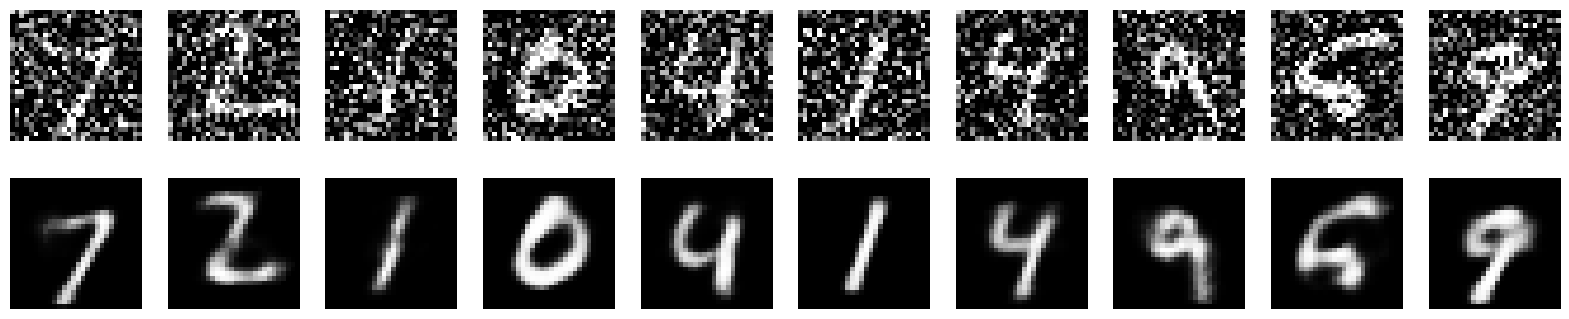

In [1]:

import tensorflow as tf             # used to build and train the neural network
from tensorflow.keras import layers # helps create neural network layers
from tensorflow.keras import models # used to connect layers into a model
import matplotlib.pyplot as plt     # used to display images

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

import numpy as np

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)


x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

x_train_noisy = x_train_noisy.reshape((len(x_train_noisy), 784))
x_test_noisy = x_test_noisy.reshape((len(x_test_noisy), 784))


input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)


decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)
autoencoder = models.Model(input_img, decoded)


autoencoder.compile(optimizer='adam', loss='binary_crossentropy')



history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)


decoded_imgs = autoencoder.predict(x_test_noisy)



n = 10
plt.figure(figsize=(20, 4))

for i in range(n):


    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

plt.show()